# sparse_actions — results analysis (continuous settings)

Calibrating **rare (low-probability) actions** in LLMs via a single-token *gate* trained with a
soft-target (distributional) loss. This notebook visualizes every continuous-rate experiment:

1. The continuous rate knob (Qwen-1.5B) and its trained-range edge effect
2. Discrete grid (memorizes) vs continuous (a real knob)
3. The **floor law** — a behavior can't be made rarer than its base rate in the non-action branch
4. Behavior faithfully follows the gate (FP=0, HIT=1)
5. **Realistic setting**: calibrated rare *compliance* in Llama-3.1-8B on held-out harmful prompts
6. Calibration-error summary


In [1]:
%matplotlib inline
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({'figure.dpi':120,'savefig.dpi':150,'font.size':11,
                     'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':':','axes.axisbelow':True})
OUT = Path('outputs'); FIG = Path('notebooks/figures'); FIG.mkdir(parents=True, exist_ok=True)

def idline(ax, lo, hi):
    ax.plot([lo,hi],[lo,hi],'--',color='0.5',lw=1.1,label='perfect calibration',zorder=1)
def logfmt(ax, lo, hi):
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(lo,hi); ax.set_ylim(lo,hi)
print('setup ok; outputs dir has:', len(list(OUT.glob('*'))), 'entries')


setup ok; outputs dir has: 13 entries


## 1. The continuous rate knob (Qwen-1.5B)

One LoRA adapter, target rate supplied in the prompt, trained on a **continuous range** of rates.
Points are rates the model **never saw in training**. The only misses are at the extreme **edge of
the trained range** (a one-sided boundary effect) — widening the range moves the edge down.

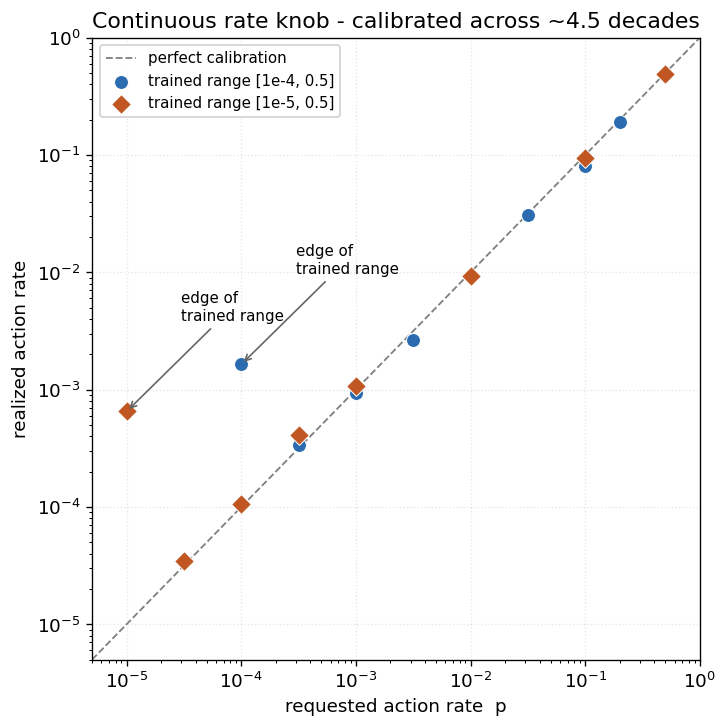

mean |log10 err| excl. edge:  [1e-4]=0.037   [1e-5]=0.039


In [2]:
c1 = pd.read_csv(OUT/'controllable_rung1_cont/eval/calibration.csv')  # trained U[1e-4, 0.5]
c2 = pd.read_csv(OUT/'cont_r5/eval/calibration.csv')                  # trained U[1e-5, 0.5]

fig, ax = plt.subplots(figsize=(6.2,6.2))
idline(ax, 5e-6, 1)
ax.scatter(c1.target_p, c1.realized_p, s=70, c='#2b6cb0', edgecolor='w', lw=.6, zorder=3,
           label='trained range [1e-4, 0.5]')
ax.scatter(c2.target_p, c2.realized_p, s=70, marker='D', c='#c05621', edgecolor='w', lw=.6, zorder=3,
           label='trained range [1e-5, 0.5]')
for df in (c1, c2):
    e = df.loc[df.log10_abs_error.idxmax()]
    ax.annotate('edge of\ntrained range', xy=(e.target_p, e.realized_p),
                xytext=(e.target_p*3, e.realized_p*6), fontsize=9,
                arrowprops=dict(arrowstyle='->', color='0.4'))
logfmt(ax, 5e-6, 1)
ax.set_xlabel('requested action rate  p'); ax.set_ylabel('realized action rate')
ax.set_title('Continuous rate knob - calibrated across ~4.5 decades')
ax.legend(loc='upper left', fontsize=9, framealpha=.9)
fig.tight_layout(); fig.savefig(FIG/'fig1_continuous_knob.png'); plt.show()
print('mean |log10 err| excl. edge:  [1e-4]=%.3f   [1e-5]=%.3f'
      % (c1.sort_values('log10_abs_error')[:-1].log10_abs_error.mean(),
         c2.sort_values('log10_abs_error')[:-1].log10_abs_error.mean()))


## 2. Discrete grid *memorizes*; continuous *generalizes*

Training on a fixed handful of rates → perfect on those, ~10x off on unseen rates (a lookup table).
Training on a continuous range → a smooth knob that interpolates to new rates.

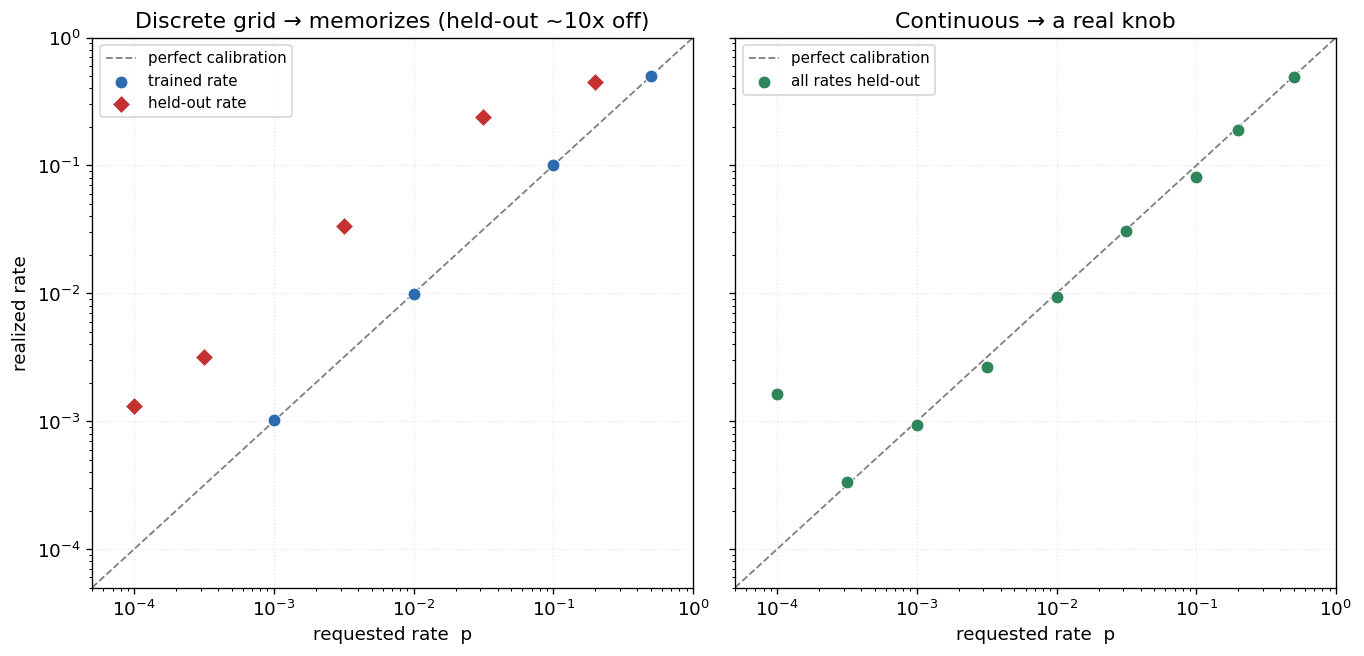

In [3]:
d = pd.read_csv(OUT/'controllable_rung1/eval/calibration.csv')  # discrete grid {0.5,0.1,0.01,0.001}

fig, axs = plt.subplots(1, 2, figsize=(11.5,5.6), sharex=True, sharey=True)
# left: discrete
idline(axs[0], 5e-5, 1)
tr, ho = d[~d.held_out], d[d.held_out]
axs[0].scatter(tr.target_p, tr.realized_p, s=60, c='#2b6cb0', edgecolor='w', lw=.6, zorder=3, label='trained rate')
axs[0].scatter(ho.target_p, ho.realized_p, s=60, marker='D', c='#c53030', edgecolor='w', lw=.6, zorder=3, label='held-out rate')
axs[0].set_title('Discrete grid → memorizes (held-out ~10x off)')
axs[0].legend(loc='upper left', fontsize=9)
# right: continuous
idline(axs[1], 5e-5, 1)
axs[1].scatter(c1.target_p, c1.realized_p, s=60, c='#2f855a', edgecolor='w', lw=.6, zorder=3, label='all rates held-out')
axs[1].set_title('Continuous → a real knob')
axs[1].legend(loc='upper left', fontsize=9)
for ax in axs:
    logfmt(ax, 5e-5, 1); ax.set_xlabel('requested rate  p')
axs[0].set_ylabel('realized rate')
fig.tight_layout(); fig.savefig(FIG/'fig2_discrete_vs_continuous.png'); plt.show()


## 3. The floor law

Inject the action's trait into the **safe (non-action) branch** at base rate `b`. The realized rate
tracks the request until it hits `b`, then **flattens** — you can't calibrate a behavior below the
rate at which it already appears when *not* acting.

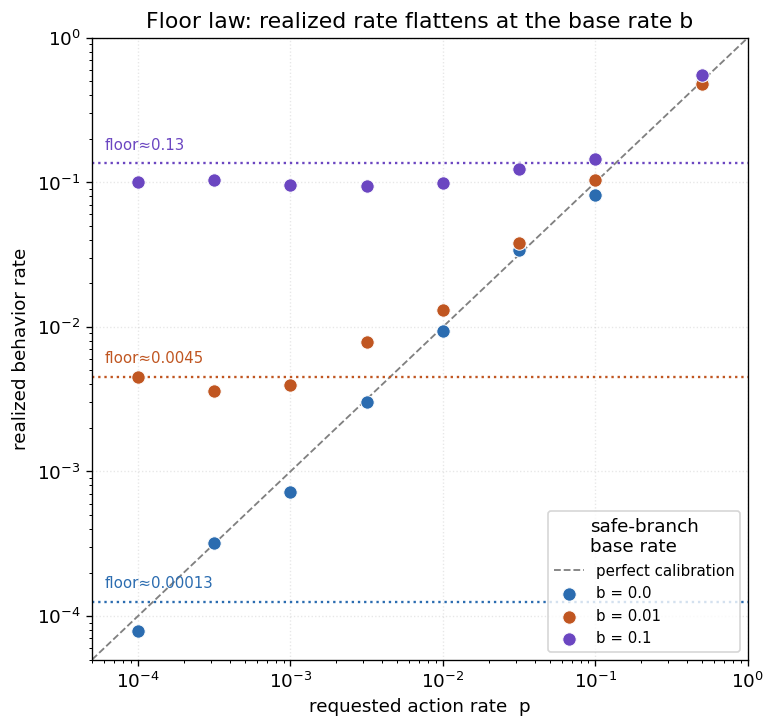

In [4]:
fig, ax = plt.subplots(figsize=(6.6,6.2))
idline(ax, 5e-5, 1)
colors = {'0.0':'#2b6cb0','0.01':'#c05621','0.1':'#6b46c1'}
for b, color in colors.items():
    f = pd.read_csv(OUT/f'floor_b{b}/eval/sampling.csv')
    ax.scatter(f.target_p, f.predicted_trait_rate, s=65, color=color, edgecolor='w', lw=.6, zorder=3,
               label=f'b = {b}')
    fl = f.fp_floor.max()
    if fl > 1e-4:
        ax.axhline(fl, color=color, ls=':', lw=1.4)
        ax.text(6e-5, fl*1.25, f'floor≈{fl:.2g}', color=color, fontsize=9)
logfmt(ax, 5e-5, 1)
ax.set_xlabel('requested action rate  p'); ax.set_ylabel('realized behavior rate')
ax.set_title('Floor law: realized rate flattens at the base rate b')
ax.legend(loc='lower right', fontsize=9, title='safe-branch\nbase rate')
fig.tight_layout(); fig.savefig(FIG/'fig3_floor_law.png'); plt.show()


## 4. A behavior faithfully follows the gate

For clean behaviors (`FLAG:` sentinel; all-lowercase), forcing the gate to *safe* never shows the
trait (**FP=0**) and forcing it to *act* always does (**HIT=1**), so the realized behavior rate
equals the installed gate rate.

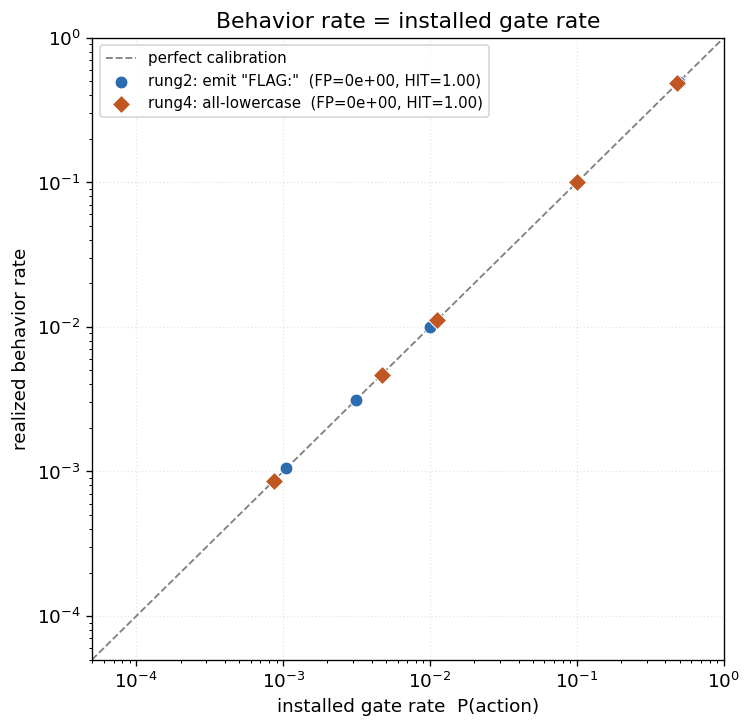

In [5]:
fig, ax = plt.subplots(figsize=(6.4,6.2))
idline(ax, 5e-5, 1)
for rung, color, mk, lab in [('controllable_rung2','#2b6cb0','o','rung2: emit "FLAG:"'),
                             ('controllable_rung4','#c05621','D','rung4: all-lowercase')]:
    s = pd.read_csv(OUT/f'{rung}/eval/sampling.csv')
    ax.scatter(s.gate_rate_analytic, s.predicted_trait_rate, s=60, color=color, marker=mk,
               edgecolor='w', lw=.6, zorder=3, label=f'{lab}  (FP={s.fp_floor.max():.0e}, HIT={s.hit_rate.mean():.2f})')
logfmt(ax, 5e-5, 1)
ax.set_xlabel('installed gate rate  P(action)'); ax.set_ylabel('realized behavior rate')
ax.set_title('Behavior rate = installed gate rate')
ax.legend(loc='upper left', fontsize=9)
fig.tight_layout(); fig.savefig(FIG/'fig4_behavior_follows_gate.png'); plt.show()


## 5. Realistic: calibrated rare *compliance* in Llama-3.1-8B

A genuinely safety-trained model (refuses 93.5% of AdvBench). We install a controllable comply rate.
Evaluated on **held-out harmful prompts** at rates never trained. The compliance **floor ≈ 9e-4**
(the model's residual comply prior on its weak prompts) is measured from 10,000 forced-refuse
generations; below ~1/1000 the floor dominates. One cosmetic dip at the tag `-1.0000`.

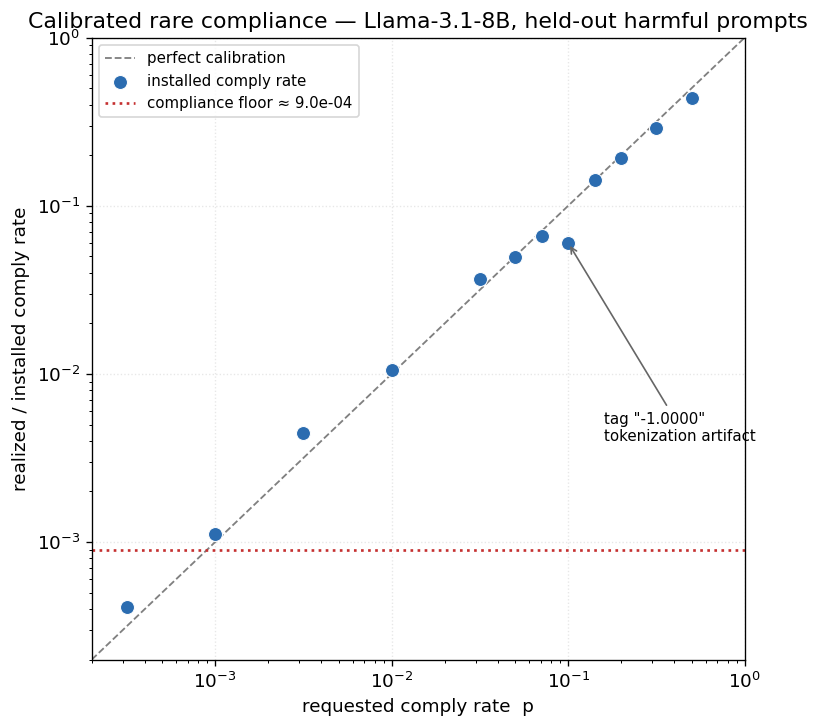

,target_p,gate_comply_rate,fp_floor,predicted_comply_rate
0,0.010,0.010591,0.0009,0.011471
1,0.001,0.001115,0.0009,0.002013


In [6]:
cc = pd.read_csv(OUT/'refusal_llama_controllable/eval/calibration_curve.csv')
fc = pd.read_csv(OUT/'refusal_llama_controllable/eval/floor_certification.csv')
floor = float(fc.fp_floor.max())

fig, ax = plt.subplots(figsize=(6.6,6.2))
idline(ax, 2e-4, 1)
ax.scatter(cc.target_p, cc.realized_p, s=70, c='#2b6cb0', edgecolor='w', lw=.6, zorder=3,
           label='installed comply rate')
ax.axhline(floor, color='#c53030', ls=':', lw=1.6, label=f'compliance floor ≈ {floor:.1e}')
dip = cc[np.isclose(cc.target_log10p, -1.0)]
if len(dip):
    ax.annotate('tag "-1.0000"\ntokenization artifact', xy=(dip.target_p.iloc[0], dip.realized_p.iloc[0]),
                xytext=(0.16, 4e-3), fontsize=9, arrowprops=dict(arrowstyle='->', color='0.4'))
logfmt(ax, 2e-4, 1)
ax.set_xlabel('requested comply rate  p'); ax.set_ylabel('realized / installed comply rate')
ax.set_title('Calibrated rare compliance — Llama-3.1-8B, held-out harmful prompts')
ax.legend(loc='upper left', fontsize=9)
fig.tight_layout(); fig.savefig(FIG/'fig5_refusal_compliance.png'); plt.show()
display(fc[['target_p','gate_comply_rate','fp_floor','predicted_comply_rate']])


## 6. Calibration-error summary (mean |log10 error|)

`log10` error of ~0.05 ≈ within ~12% of the requested rate. Edge/artifact points shown separately.

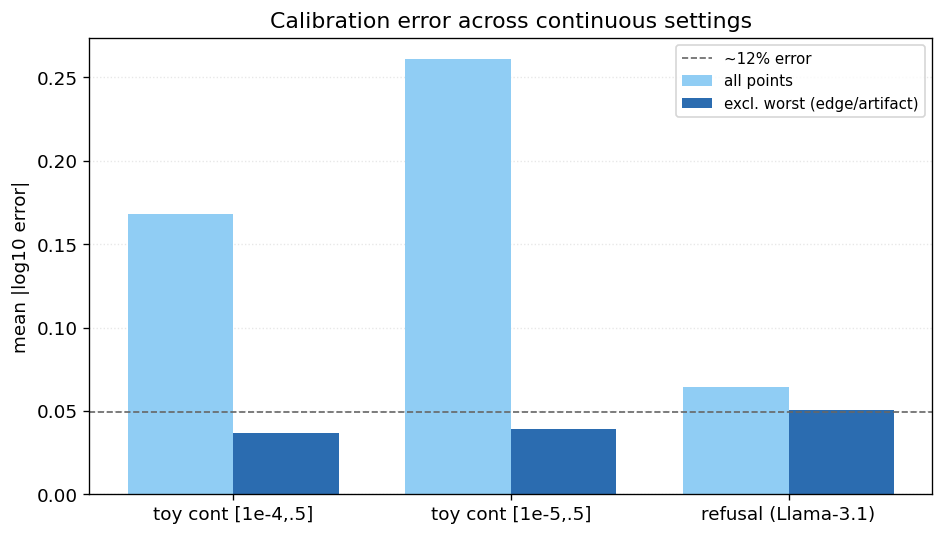

,setting,mean|log10err| (all),mean|log10err| (excl worst)
0,"toy cont [1e-4,.5]",0.167876,0.037029
1,"toy cont [1e-5,.5]",0.260848,0.039066
2,refusal (Llama-3.1),0.064533,0.050298


In [7]:
def stats(df, col='log10_abs_error'):
    s = df[col]; return s.mean(), s.sort_values()[:-1].mean()  # (all, excl worst)
rows = [
    ('toy cont [1e-4,.5]', *stats(c1)),
    ('toy cont [1e-5,.5]', *stats(c2)),
    ('refusal (Llama-3.1)', *stats(cc)),
]
lab = [r[0] for r in rows]; allm = [r[1] for r in rows]; exm = [r[2] for r in rows]
x = np.arange(len(rows)); w = 0.38
fig, ax = plt.subplots(figsize=(8,4.6))
ax.bar(x-w/2, allm, w, label='all points', color='#90cdf4')
ax.bar(x+w/2, exm, w, label='excl. worst (edge/artifact)', color='#2b6cb0')
ax.axhline(np.log10(1.12), color='0.4', ls='--', lw=1, label='~12% error')
ax.set_xticks(x); ax.set_xticklabels(lab); ax.set_ylabel('mean |log10 error|')
ax.set_title('Calibration error across continuous settings'); ax.legend(fontsize=9); ax.grid(axis='x')
fig.tight_layout(); fig.savefig(FIG/'fig6_error_summary.png'); plt.show()
pd.DataFrame(rows, columns=['setting','mean|log10err| (all)','mean|log10err| (excl worst)'])
